# Process and reformat tecan data, then background normalize the NGAC assay for upload to HiTS

In [402]:
import pandas as pd
import string
import sys
sys.path.append("/Users/apaulson/repos/data-proc")
import plate_maps as pm
import seaborn as sns
import numpy as np

In [403]:
dat = pd.read_csv("/Volumes/Shared/SMDC/Screens/2025_users_temp/Deepthi/all_data/AMP glo assay rawdata.csv")

# find starting/ending index
label_col = dat.columns[0]

start_row = dat.loc[dat[label_col].eq("Cycle Nr.")].index[0]
end_row = dat.loc[dat[label_col].eq("End Time")].index[0]
dat=dat[start_row:end_row]

dat=dat.dropna(how='all', axis=0)
dat.columns=dat.iloc[0]
dat=dat[1:]
dat=dat.T
dat.columns=dat.iloc[1]
dat=dat[3:]
dat=dat.reset_index(names='well')
dat['row'] = dat['well'].str.extract('([A-Z]+)')
dat['col'] = dat['well'].str.extract('(\d+)')
dat['col'] = dat['col'].astype(int)
dat=dat.melt(id_vars=['well', 'row', 'col'], var_name='time', value_name='intensity')
dat['well'] = dat['row'] + dat['col'].astype(str).str.zfill(2)
dat.intensity=dat.intensity.astype(float)
dat.time=dat.time.astype(float)
dat

,well,row,col,time,intensity
0,A01,A,1,0.000,1007.0
1,A02,A,2,0.000,963.0
2,A03,A,3,0.000,1155.0
3,A04,A,4,0.000,937.0
4,A05,A,5,0.000,1027.0
...,...,...,...,...,...
4603,P20,P,20,6600.145,10.0
4604,P21,P,21,6600.145,6.0
4605,P22,P,22,6600.145,21.0
4606,P23,P,23,6600.145,8.0


In [404]:
platemap=pd.read_excel("/Volumes/Shared/SMDC/Screens/2025_users_temp/Deepthi/all_data/NCAG_DR_TC.xlsx", sheet_name=None)
platemap.keys()

dict_keys(['Info', 'TARG_AMPglo_P1', 'TARG_AMPglo_ctrl_P1'])

In [405]:
platemap['Info']

,Grid_num,Source_plate,Assay_name,Raw_assay_ID,Date_of_screen,Raw_data_file,Comments,Control,Control_lot
0,TARG_AMPglo_P1,NaN,TARG_AMPglo,2807,2026-02-06,/Volumes/Shared/SMDC/Screens/2025_users_temp/D...,TECAN TIMECOURSE,NaN,NaN
1,TARG_AMPglo_ctrl_P1,NaN,TARG_AMPglo_counter,2809,2026-02-06,/Volumes/Shared/SMDC/Screens/2025_users_temp/D...,TECAN TIMECOURSE,NaN,NaN


In [406]:
nudt5=pm.read_platemap_block(platemap['TARG_AMPglo_ctrl_P1'], block=0, value_name='SMDC_ID')
nudt5=nudt5[nudt5.SMDC_ID=='NUDT5']
nudt5['well']=nudt5.row+nudt5.col.astype(str).str.zfill(2)
nudt5_wells=nudt5.well.unique()
len(nudt5_wells)

60

In [407]:
ids=pm.read_platemap_block(platemap['TARG_AMPglo_P1'], block=0, value_name='SMDC_ID')
ids=ids.dropna(subset=['SMDC_ID'])
ids['well']=ids.row+ids.col.astype(str).str.zfill(2)
ids.head()

,row,col,SMDC_ID,well
0,A,01,1128295,A01
1,B,01,1128295,B01
2,C,01,1128295,C01
3,D,01,1128295,D01
4,E,01,1128295,E01


In [408]:
all_ids=pd.concat([ids])

In [409]:
dat_id=dat.merge(all_ids[['well', 'SMDC_ID']], on='well', how='left')
dat_id['nudt5_only']=dat_id['well'].isin(nudt5_wells)

In [410]:
concs=pm.read_platemap_block(platemap['TARG_AMPglo_P1'], block=1, value_name='conc')
concs=concs.dropna(subset=['conc'])
concs['well']=concs.row+concs.col.astype(str).str.zfill(2)
concs=concs[['well', 'conc']]
dat_id_conc=dat_id.merge(concs, on='well', how='left')

In [411]:
dat_id_conc.SMDC_ID.unique()

array([1128295, 1128944, 1128230, 1128834, nan, 'positive control',
       'Negative control'], dtype=object)

In [412]:
dat_id_conc.head()

,well,row,col,time,intensity,SMDC_ID,nudt5_only,conc
0,A01,A,1,0.0,1007.0,1128295,False,100
1,A02,A,2,0.0,963.0,1128295,False,100
2,A03,A,3,0.0,1155.0,1128295,False,100
3,A04,A,4,0.0,937.0,1128944,False,100
4,A05,A,5,0.0,1027.0,1128944,False,100


In [413]:
dat_id_conc.conc=dat_id_conc.conc.fillna(0)
print(dat_id_conc.shape)
dat_id_conc=dat_id_conc.dropna(subset=['SMDC_ID'])
dat_id_conc.SMDC_ID=dat_id_conc.SMDC_ID.astype(str)
print(dat_id_conc.shape)

(4608, 8)
(1728, 8)


In [414]:
dat_id_conc[['nudt5_only', 'SMDC_ID']].value_counts()

nudt5_only  SMDC_ID         
False       1128230             180
            1128295             180
            1128834             180
            1128944             180
True        1128230             180
            1128295             180
            1128834             180
            1128944             180
False       Negative control    144
            positive control    144
Name: count, dtype: int64

In [449]:
dat_id_conc['intensity_bgsub']=None
dat_id_conc['intensity_activity']=None
dat_id_conc['intensity_inhibition']=None
for time in dat_id_conc.time.unique():
    dat_time=dat_id_conc[dat_id_conc.time==time].copy()

    dat_time_ctrl_mean=dat_time[(dat_time.nudt5_only==True)&(dat_time.conc!=100)].intensity.mean()
    dat_time['intensity_bgsub']=dat_time.intensity-dat_time_ctrl_mean
    dat_id_conc.loc[dat_id_conc.time==time, 'intensity_bgsub']=dat_time.intensity_bgsub

    dat_time_pos_mean=dat_time[dat_time.SMDC_ID=='positive control'].intensity_bgsub.mean() # don't flip the control
    dat_time_neg_mean=dat_time[dat_time.SMDC_ID=='Negative control'].intensity_bgsub.mean() # don't flip the control

    dat_id_conc.loc[dat_id_conc.time==time, 'intensity_activity']=(dat_id_conc.intensity_bgsub-dat_time_neg_mean)/(dat_time_pos_mean-dat_time_neg_mean)*100
    dat_id_conc.loc[dat_id_conc.time==time, 'intensity_inhibition']=100-dat_id_conc.intensity_activity
dat_id_conc

,well,row,col,time,intensity,SMDC_ID,nudt5_only,conc,intensity_bgsub,intensity_activity,intensity_inhibition,log_conc_M
0,I09,I,9,4200.092,5182.0,1128230,True,12.5,-33.145833,4.527805,95.472195,-4.90309
1,J08,J,8,600.010,1668.0,1128230,True,6.25,-32.833333,-2.762253,102.762253,-5.20412
2,J07,J,7,600.010,1745.0,1128230,True,6.25,44.166667,0.952917,99.047083,-5.20412
3,I07,I,7,2400.053,3881.0,1128230,True,12.5,123.354167,6.640421,93.359579,-4.90309
4,I08,I,8,2400.053,3609.0,1128230,True,12.5,-148.645833,0.550414,99.449586,-4.90309
...,...,...,...,...,...,...,...,...,...,...,...,...
1723,K10,K,10,4800.100,11830.0,positive control,False,0,6226.875,102.291427,-2.291427,NaN
1724,K12,K,12,1800.038,6756.0,positive control,False,0,3618.208333,100.224629,-0.224629,NaN
1725,K11,K,11,1800.038,6591.0,positive control,False,0,3453.208333,95.821008,4.178992,NaN
1726,K03,K,3,2400.053,8329.0,positive control,False,0,4571.354167,106.229943,-6.229943,NaN


In [450]:
dat_id_conc=dat_id_conc.sort_values('SMDC_ID').reset_index(drop=True)

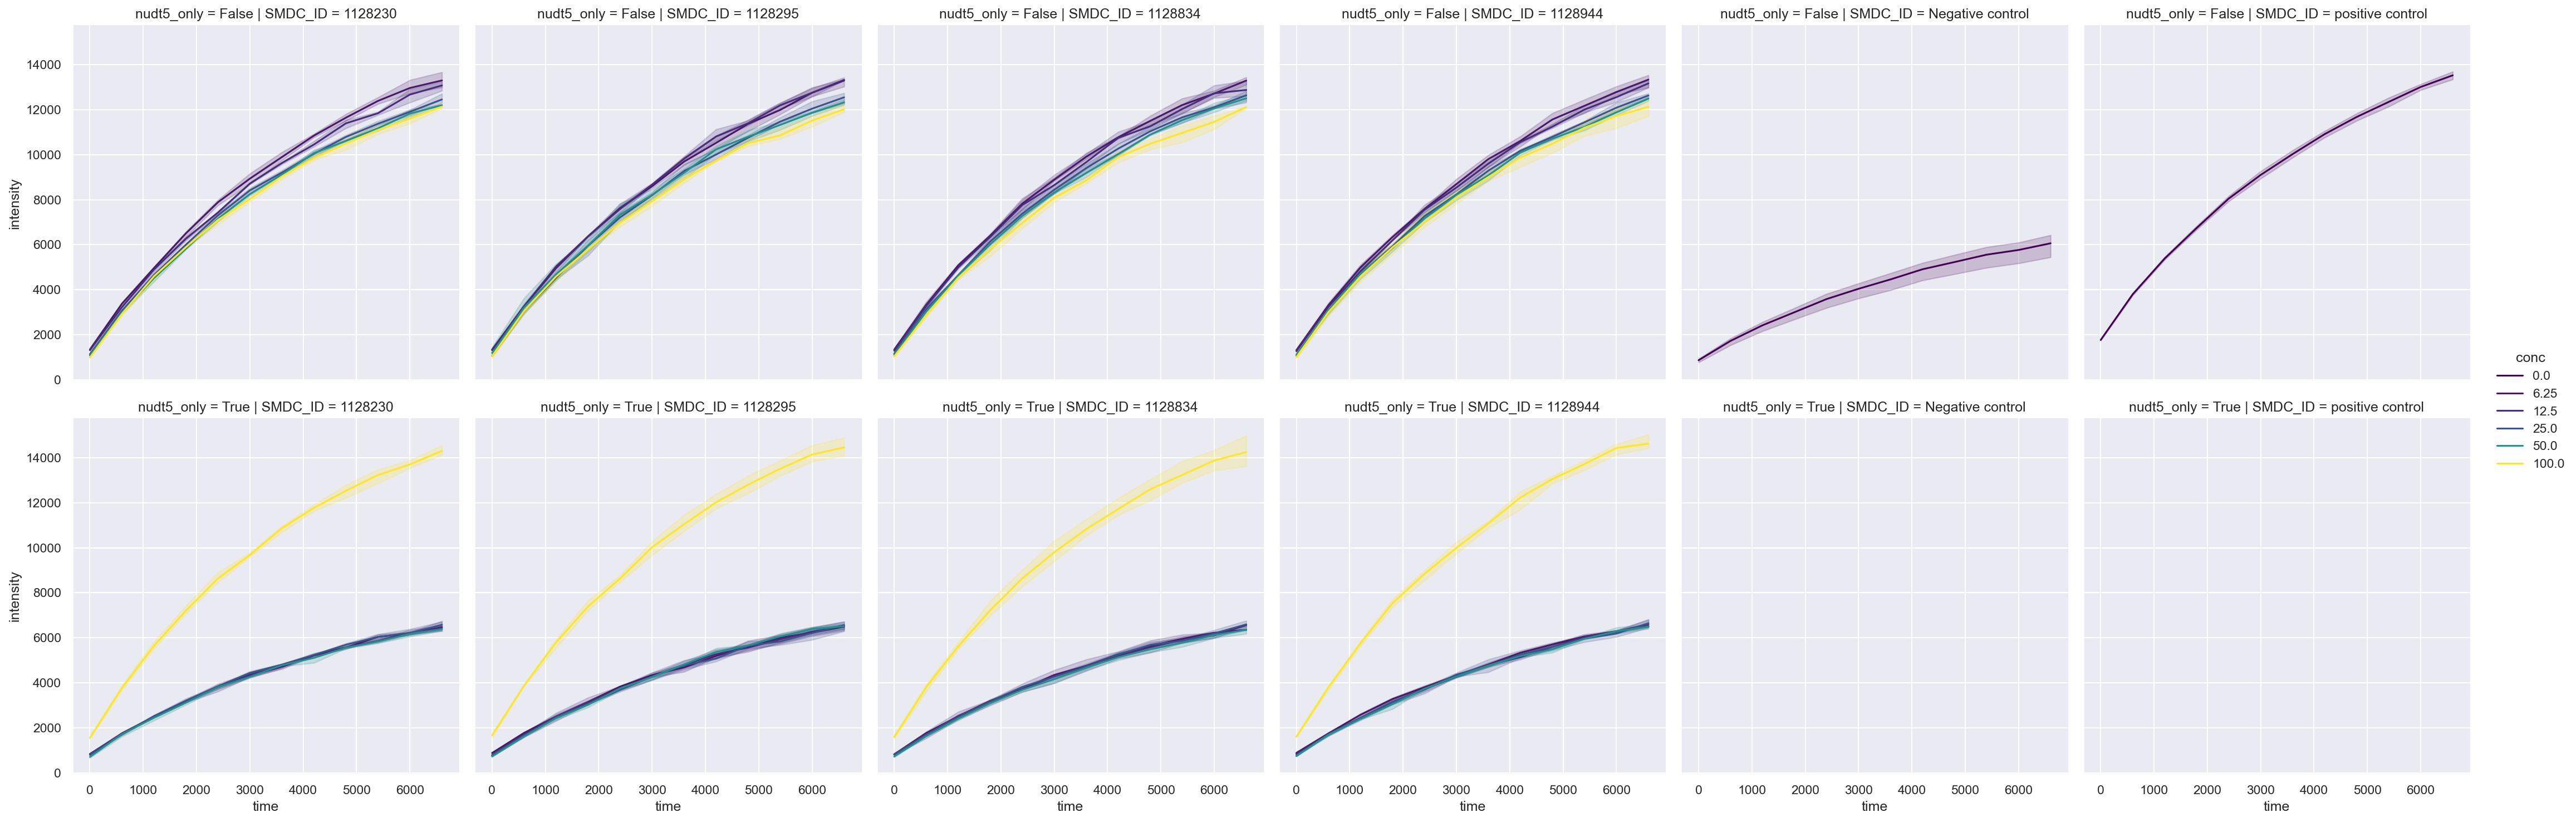

In [451]:
sns.relplot(data=dat_id_conc, x='time', y='intensity', hue='conc', col='SMDC_ID', row='nudt5_only', palette='viridis', kind='line')

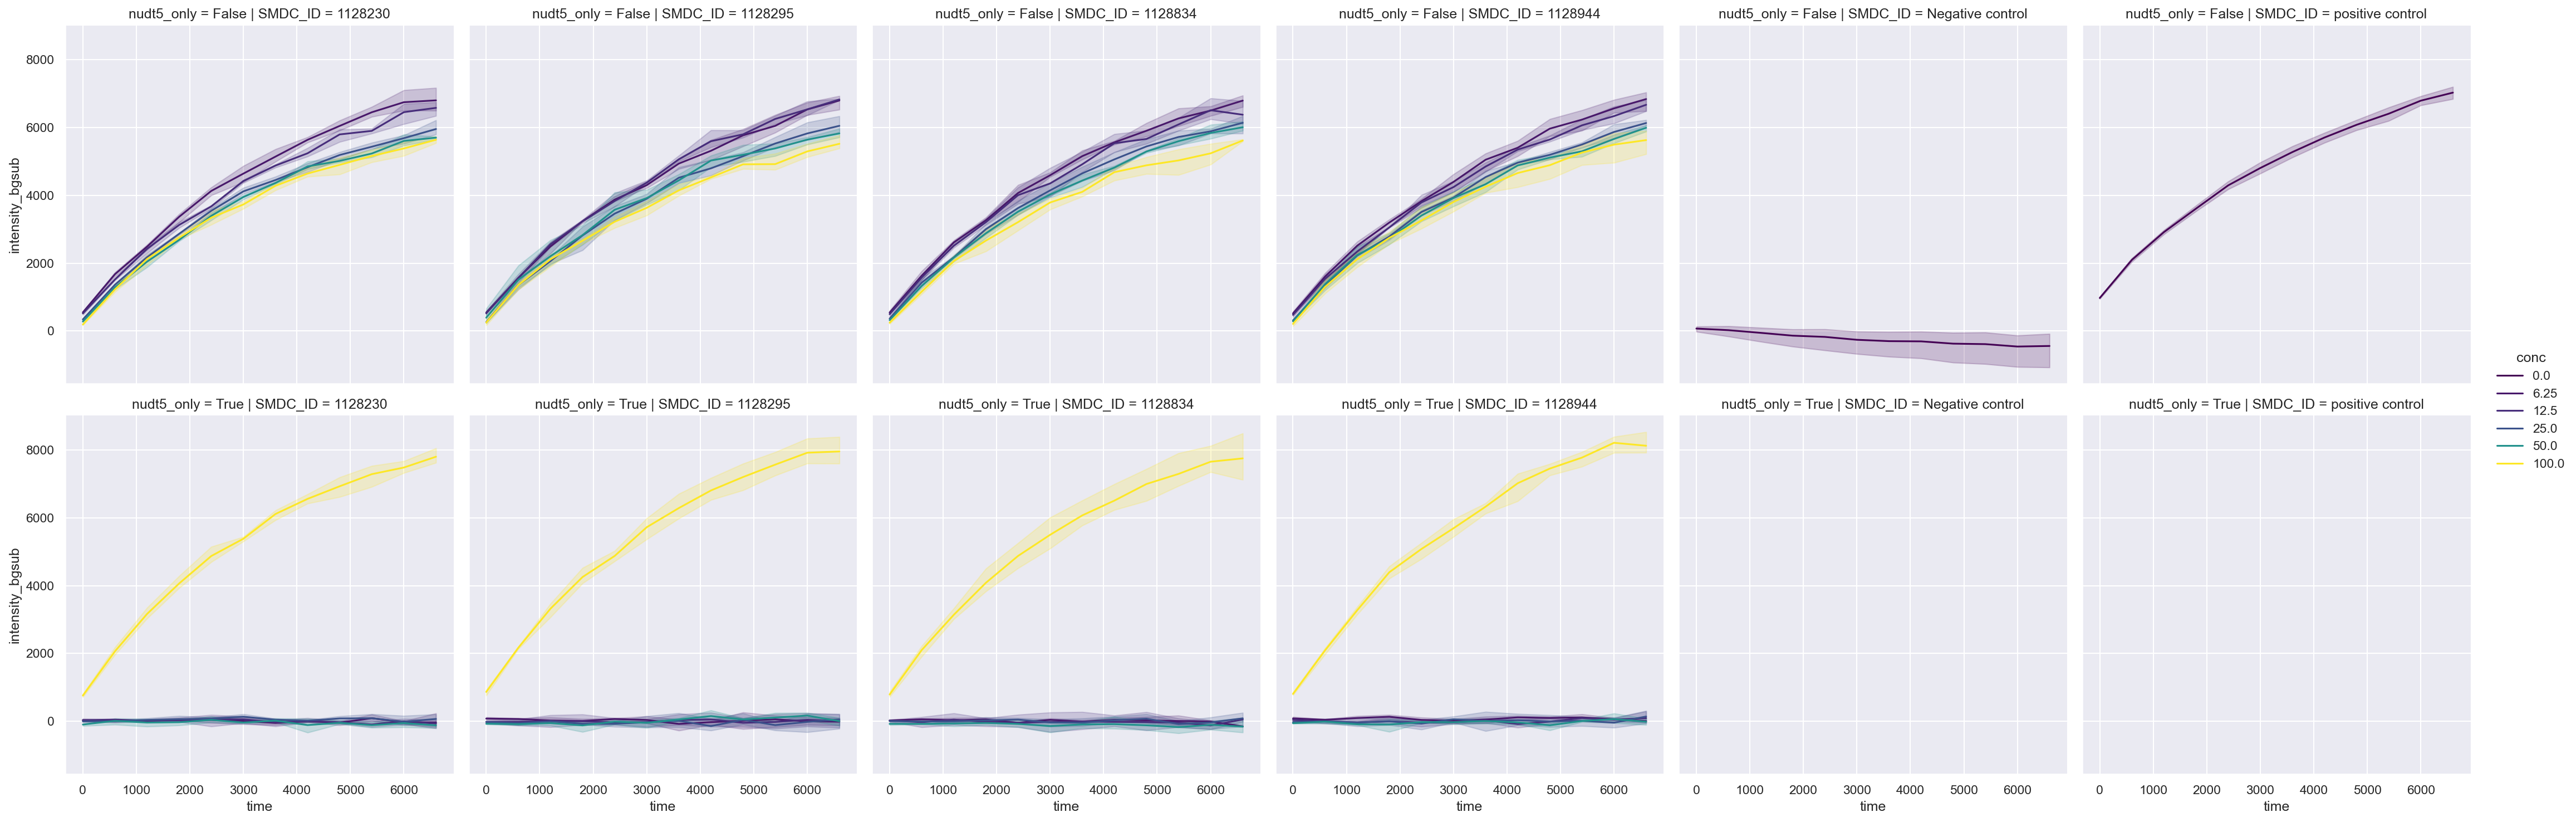

In [452]:
sns.relplot(data=dat_id_conc, x='time', y='intensity_bgsub', hue='conc', col='SMDC_ID', row='nudt5_only', palette='viridis', kind='line')

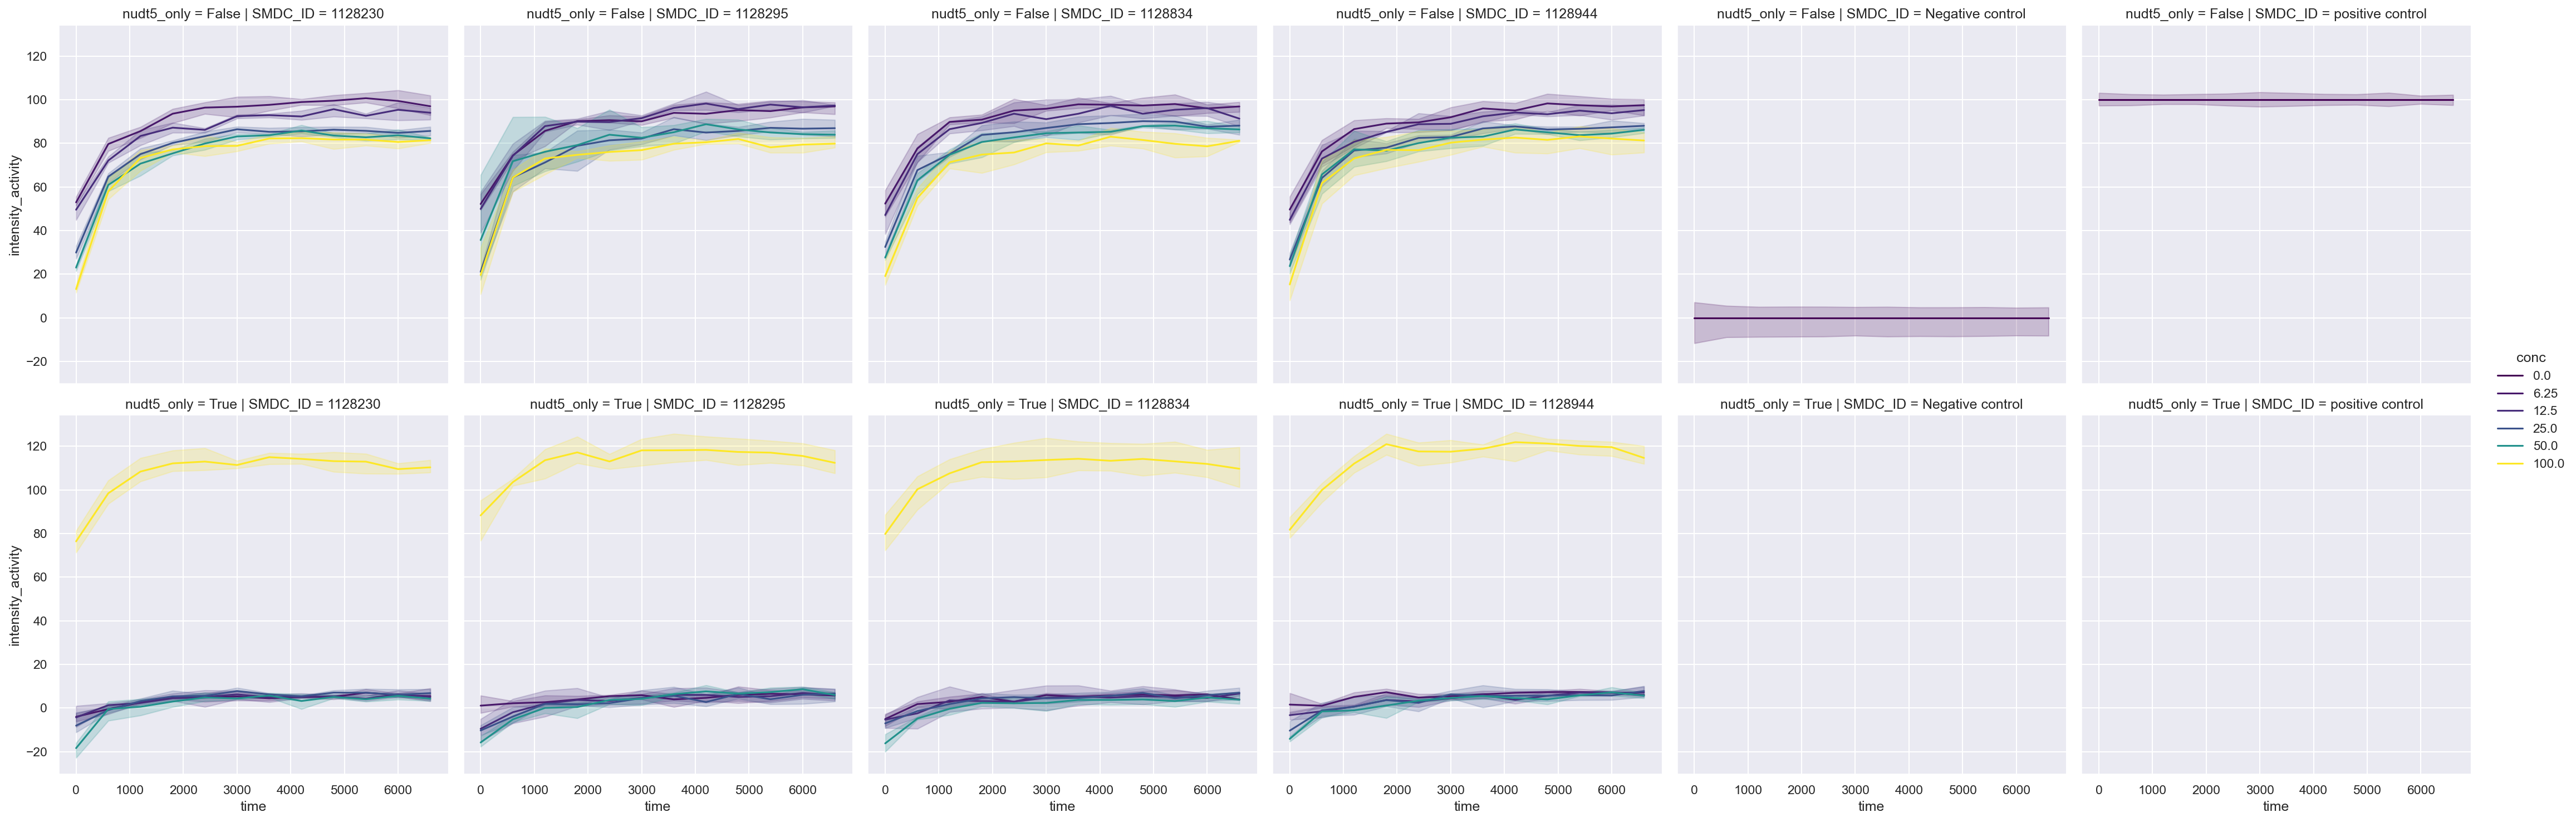

In [453]:
sns.relplot(data=dat_id_conc, x='time', y='intensity_activity', hue='conc', col='SMDC_ID', row='nudt5_only', palette='viridis', kind='line')

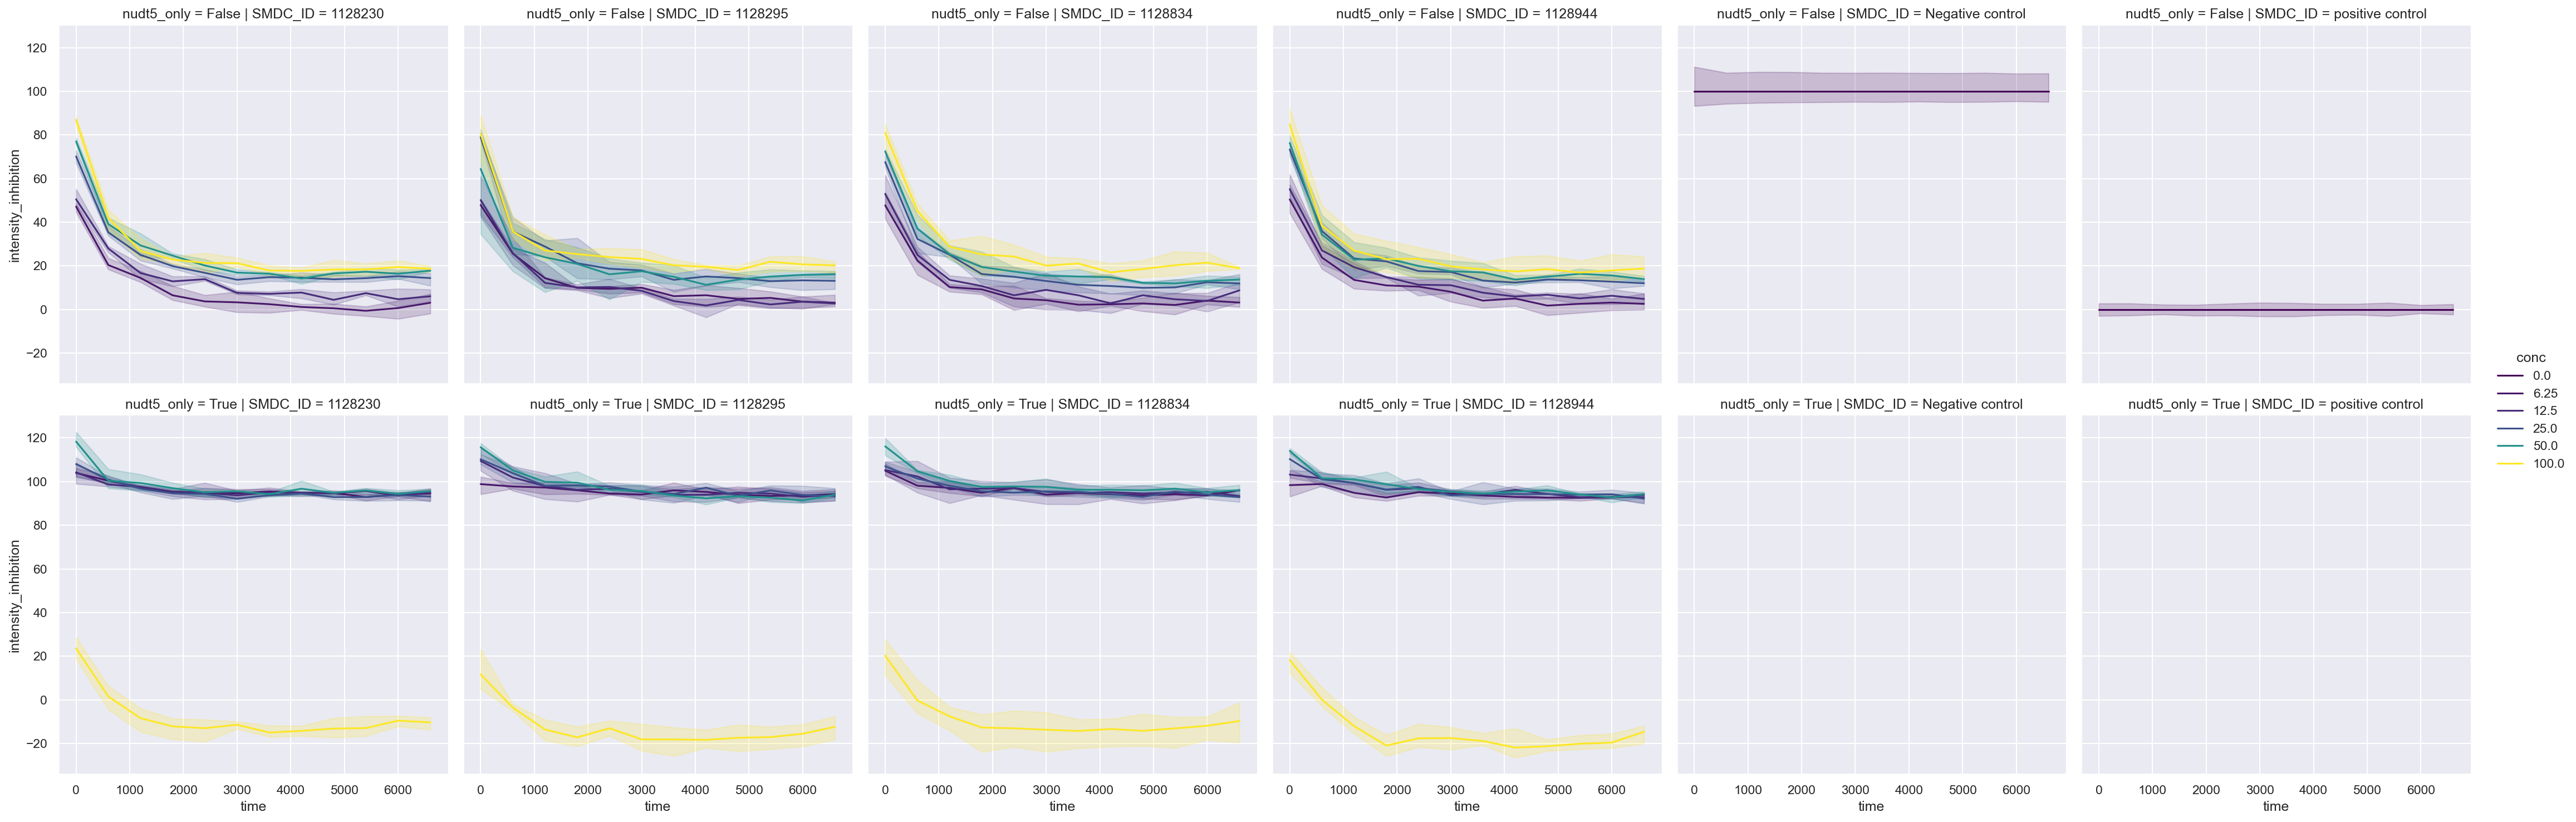

In [455]:
sns.relplot(data=dat_id_conc, x='time', y='intensity_inhibition', hue='conc', col='SMDC_ID', row='nudt5_only', palette='viridis', kind='line')

In [456]:
dat_id_conc.time.unique()

array([4200.092, 1800.038, 3600.086, 6000.129,    0.   , 5400.119,
       3000.071,  600.01 , 2400.053, 1200.023, 6600.145, 4800.1  ])

In [457]:
dat_id_conc['log_conc_M']=dat_id_conc.conc.apply(lambda x: np.log10(x/1000000) if x>0 else np.nan)

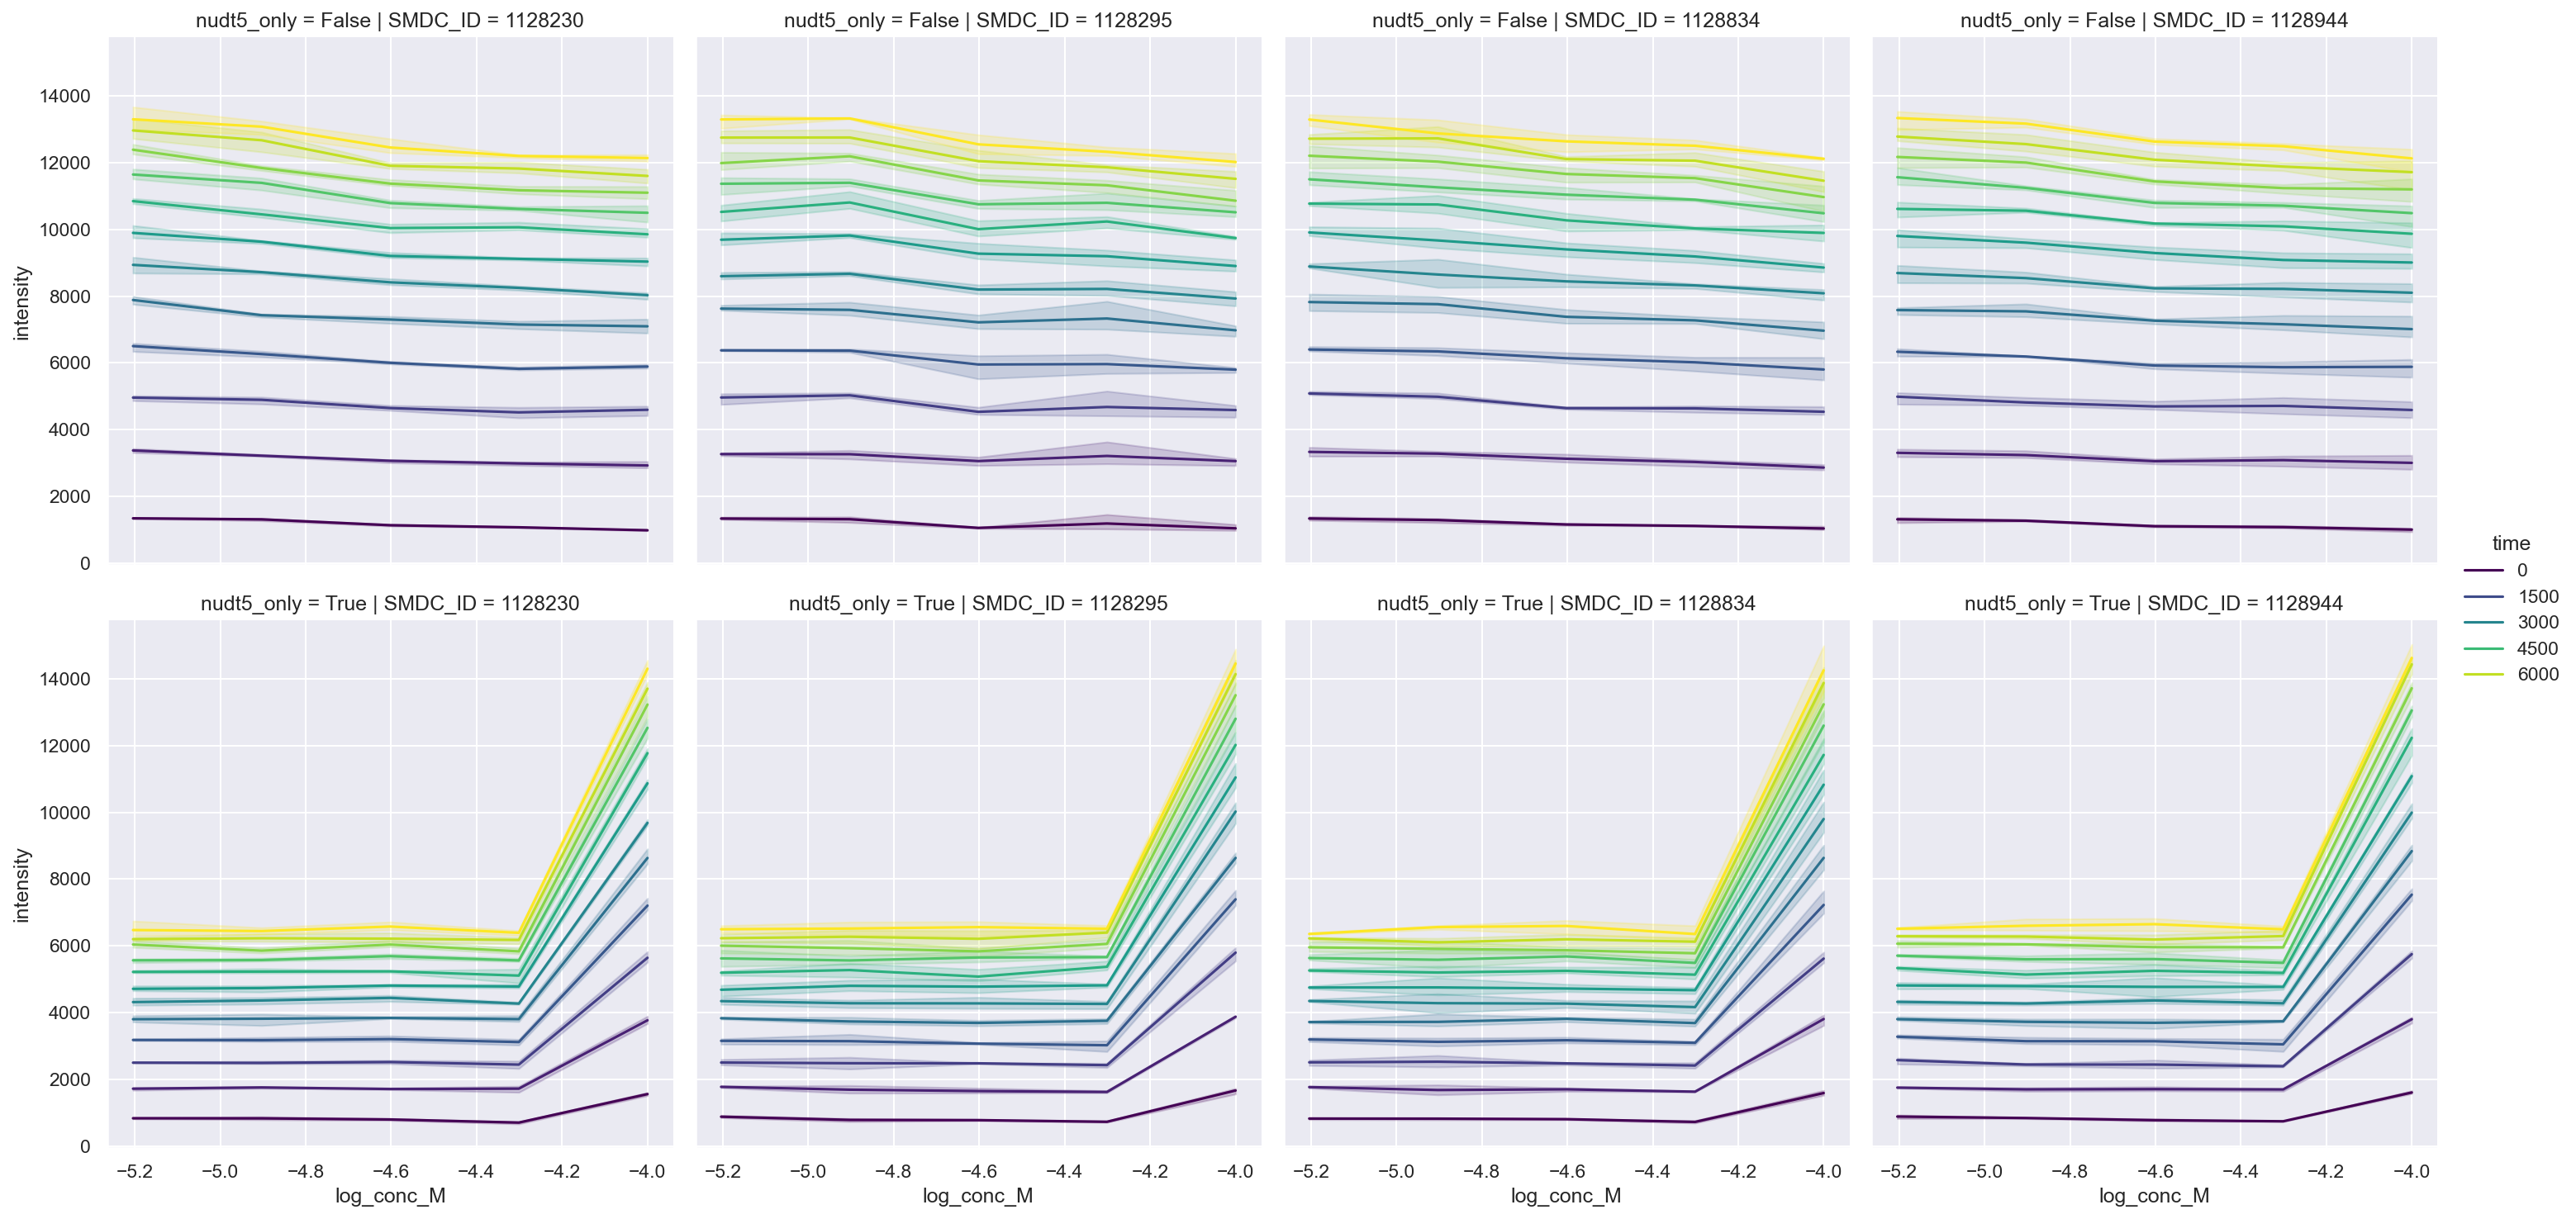

In [458]:
sns.relplot(data=dat_id_conc[dat_id_conc.log_conc_M.notna()], x='log_conc_M', y='intensity', hue='time', col='SMDC_ID', row='nudt5_only', palette='viridis', kind='line')

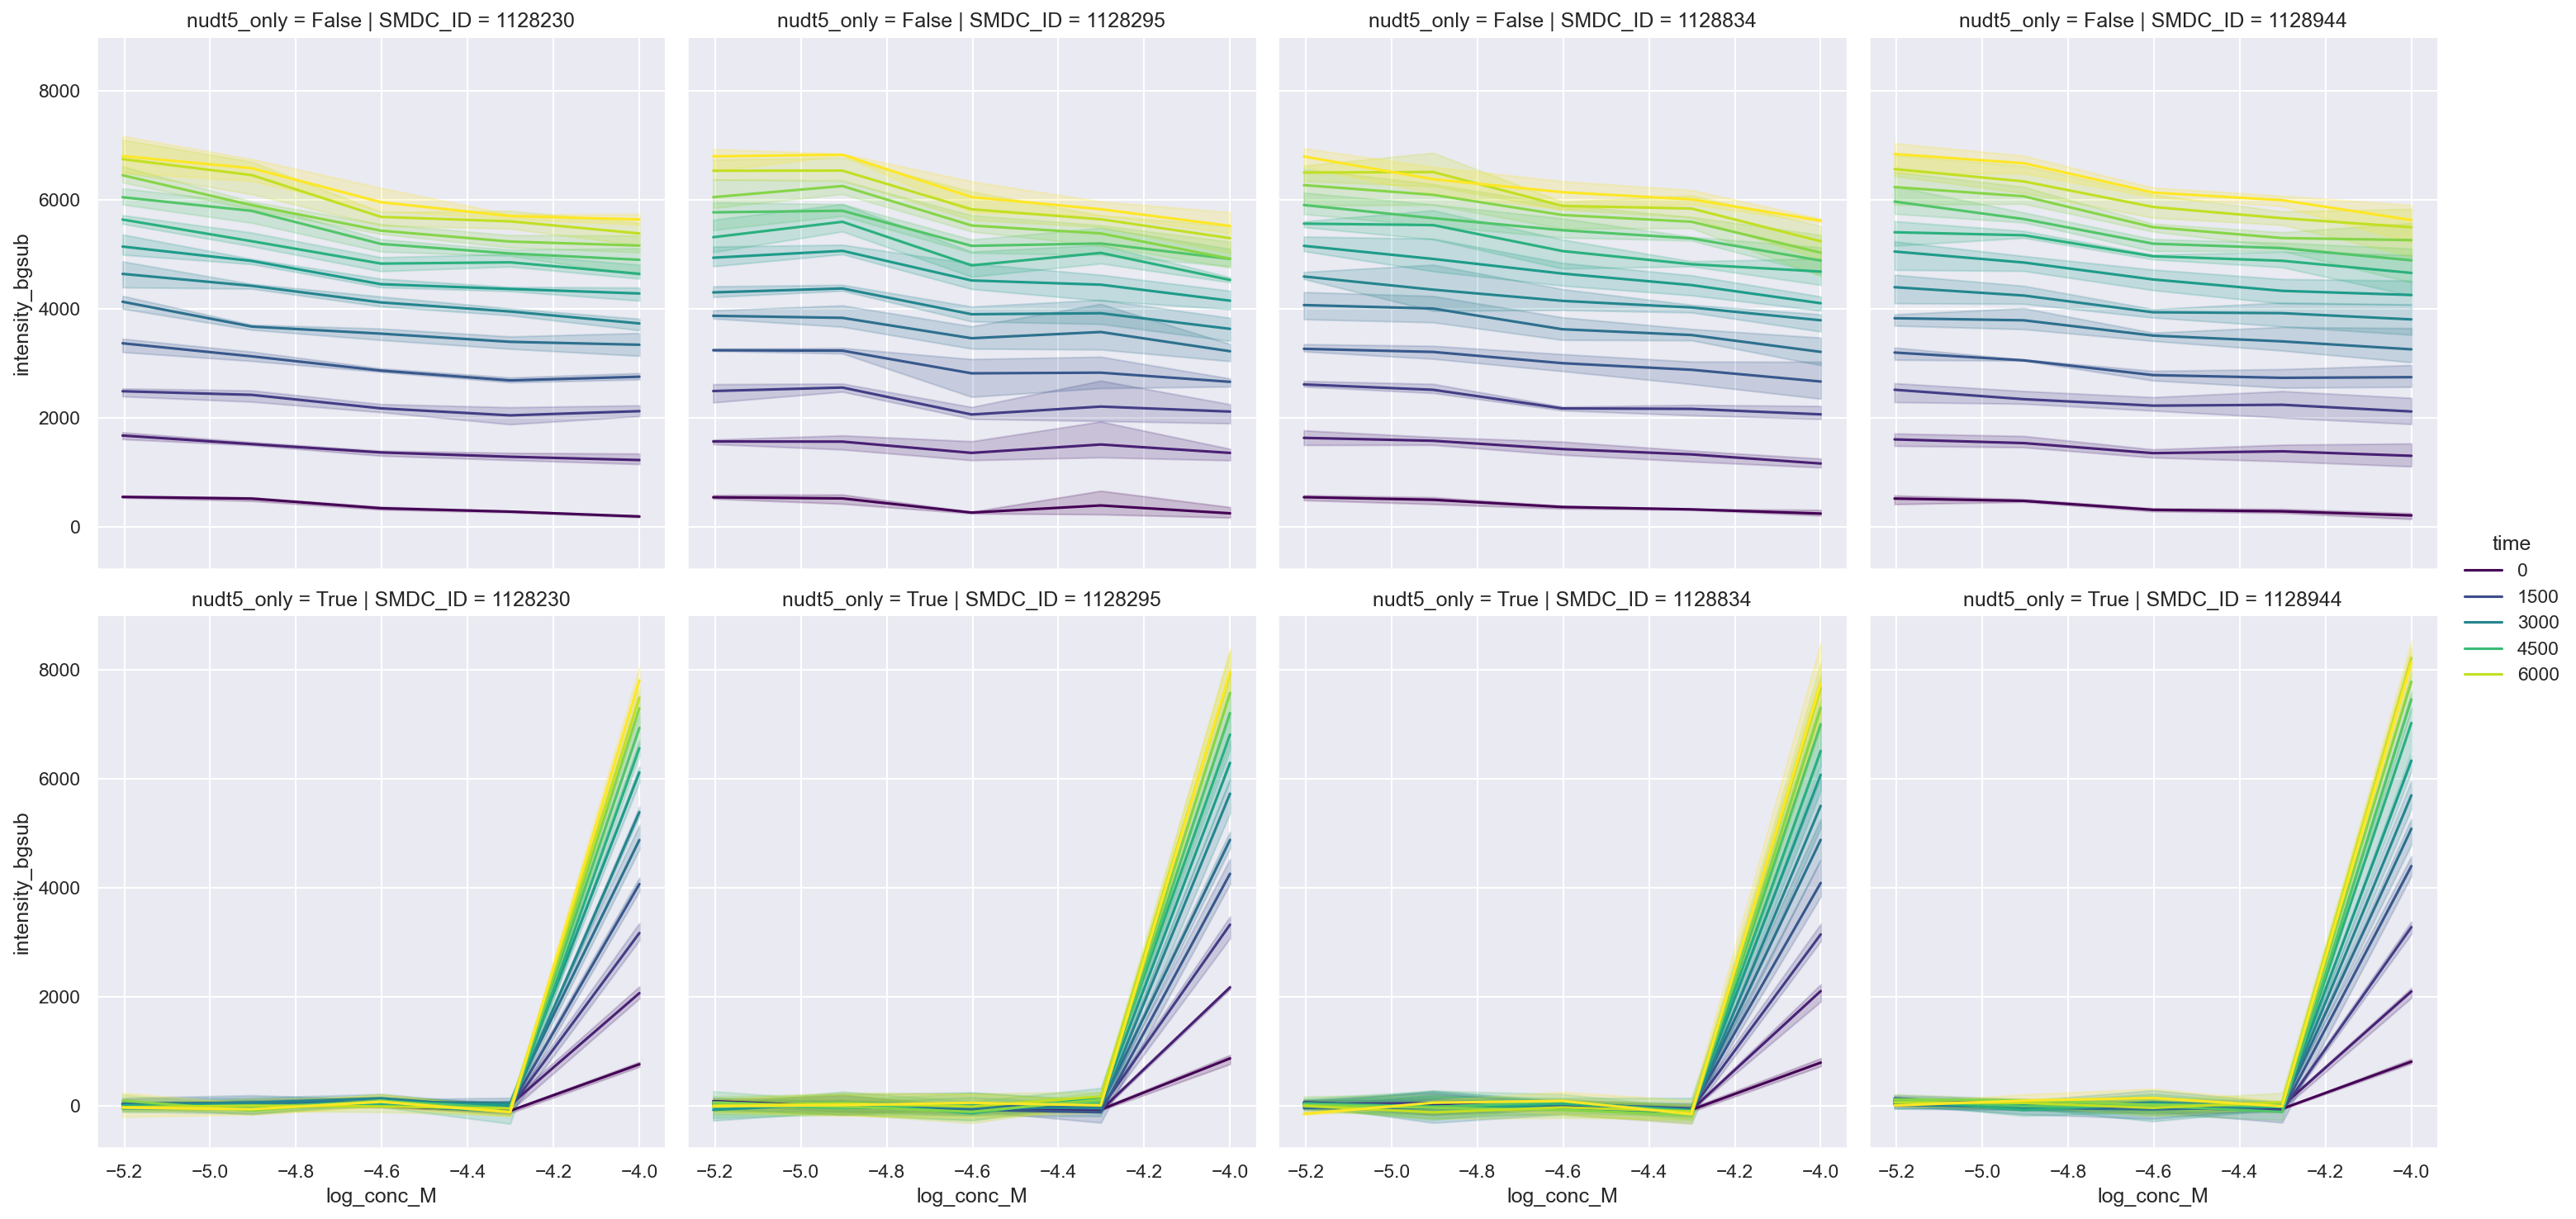

In [459]:
sns.relplot(data=dat_id_conc[dat_id_conc.log_conc_M.notna()], x='log_conc_M', y='intensity_bgsub', hue='time', col='SMDC_ID', row='nudt5_only', palette='viridis', kind='line')

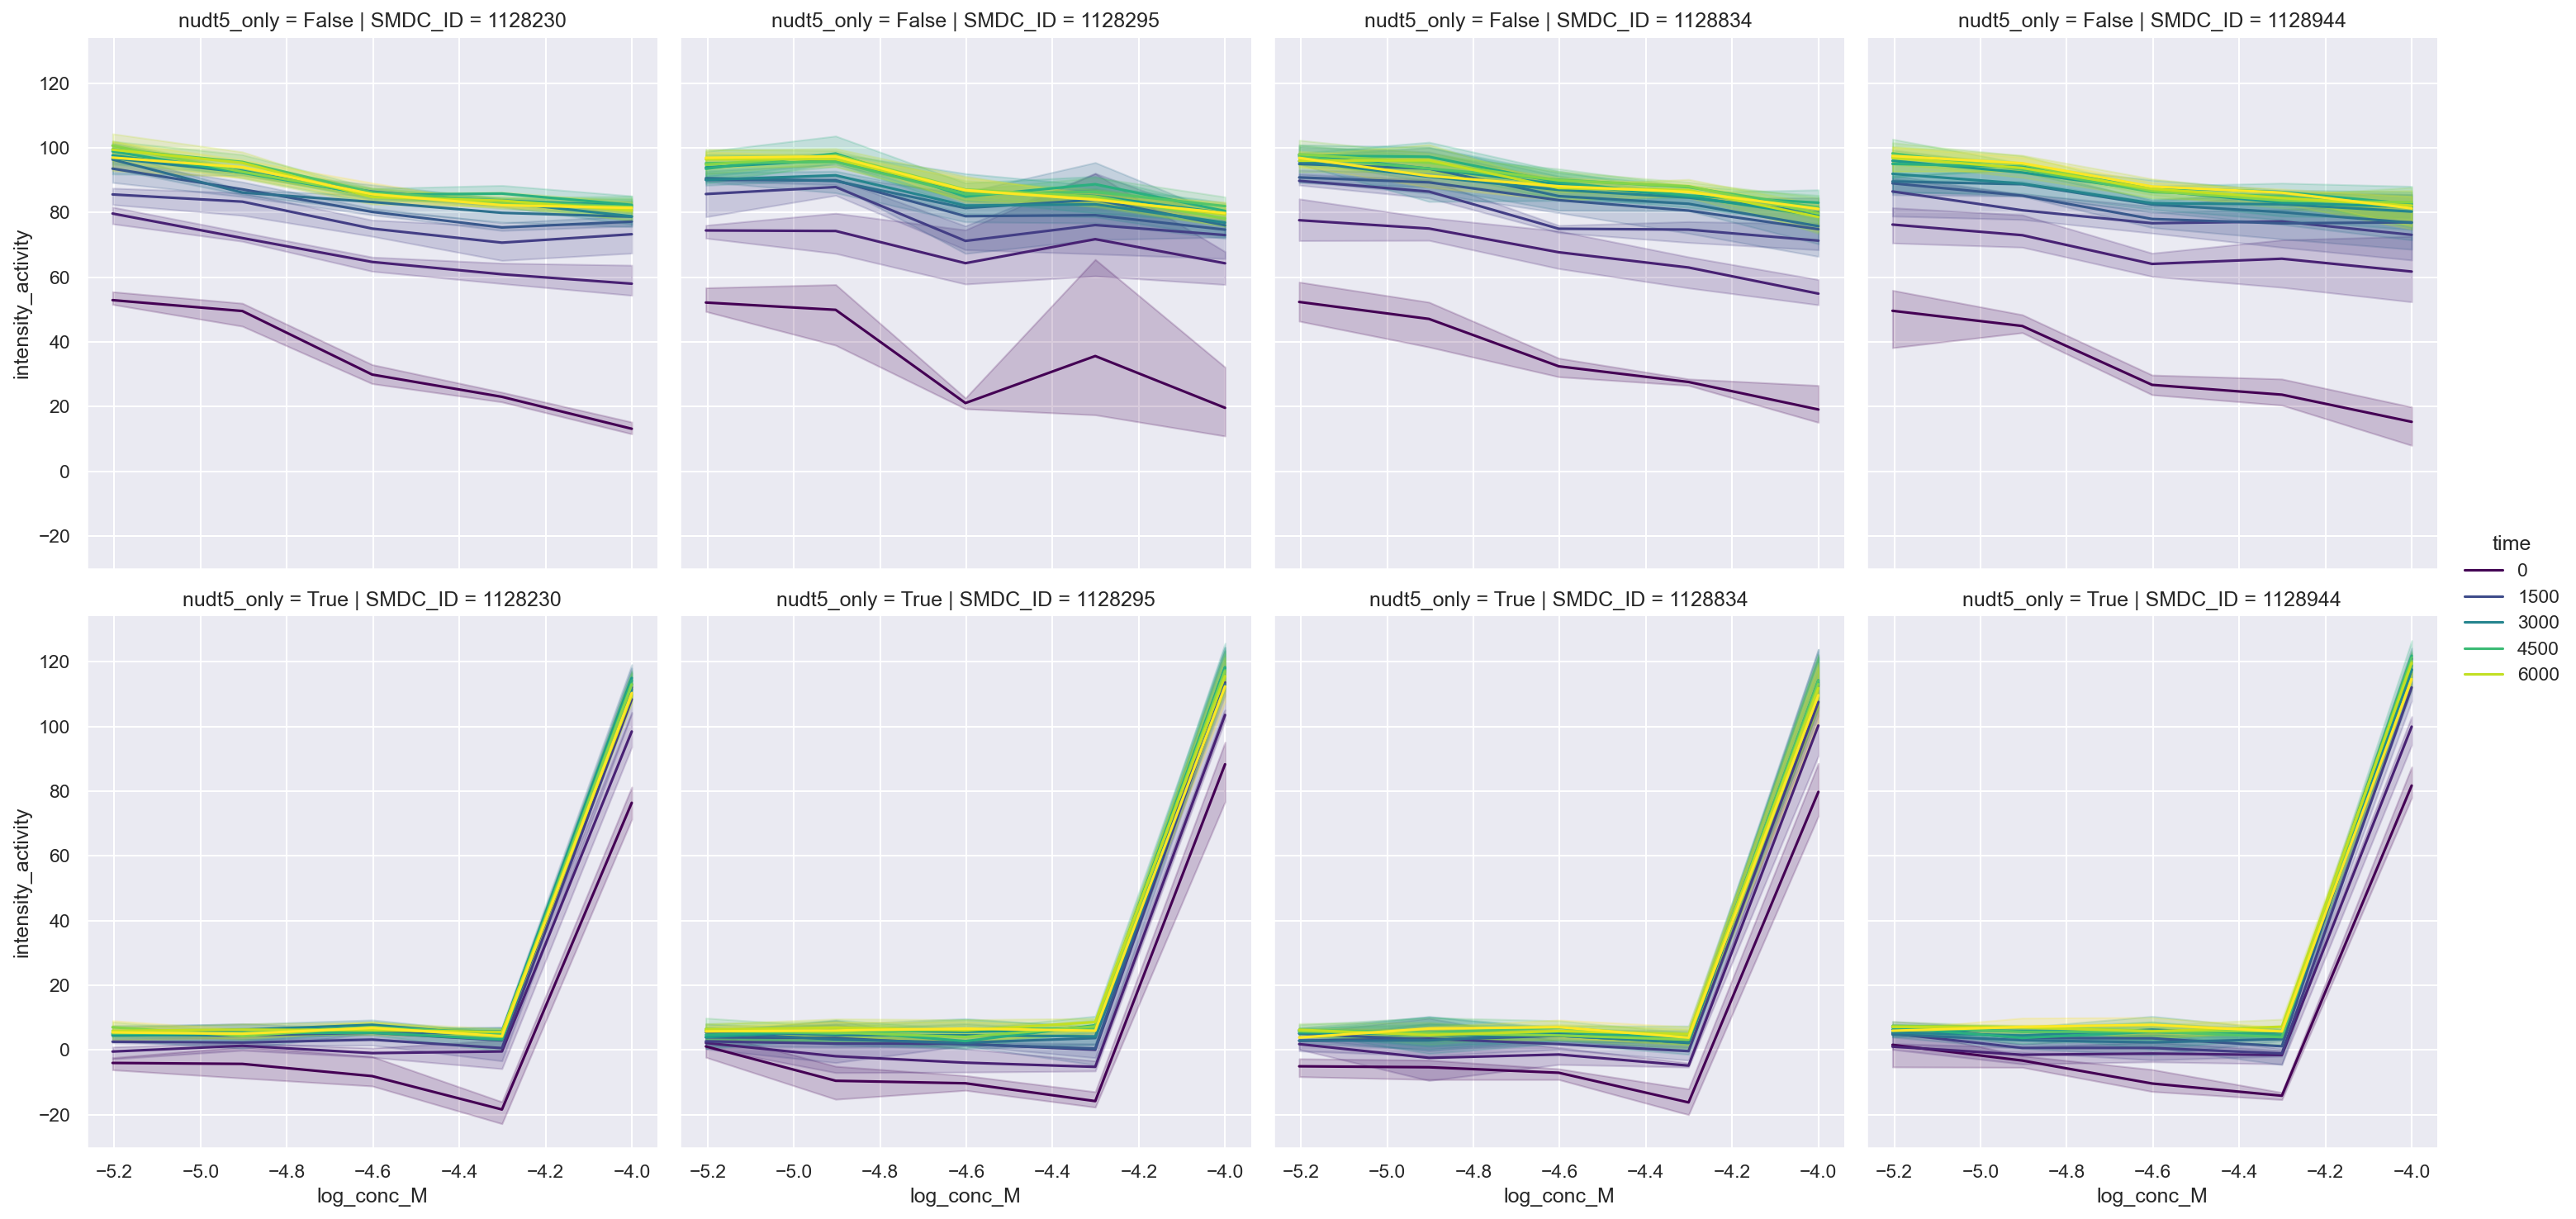

In [461]:
sns.relplot(data=dat_id_conc[dat_id_conc.log_conc_M.notna()], x='log_conc_M', y='intensity_activity', hue='time', col='SMDC_ID', row='nudt5_only', palette='viridis', kind='line')

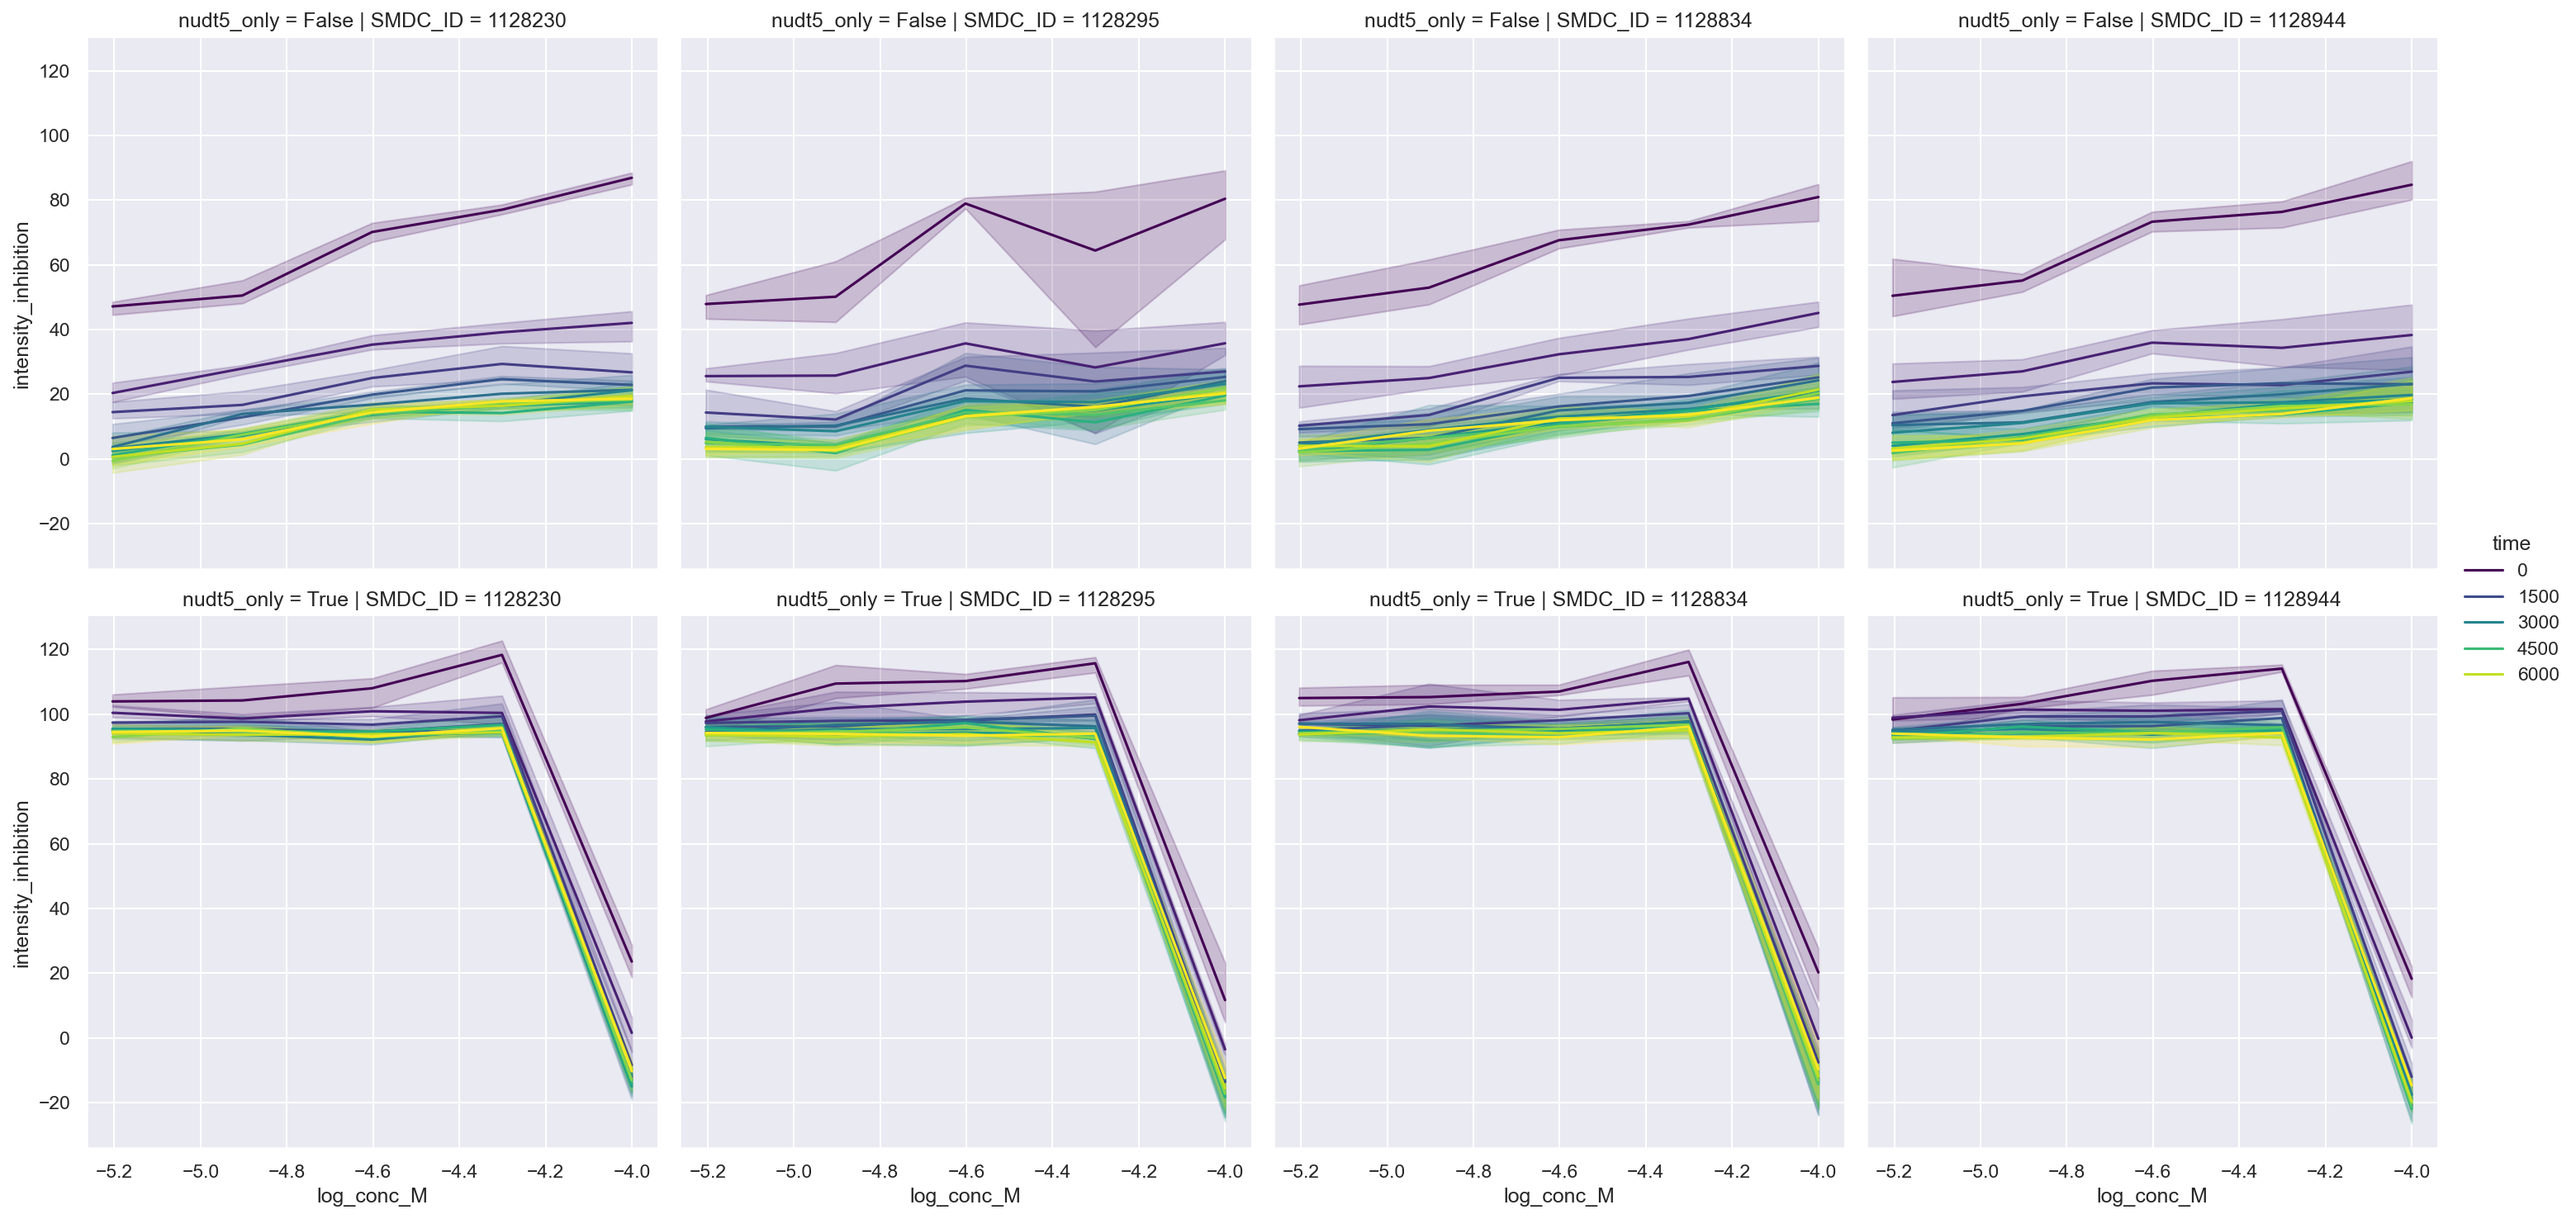

In [462]:
sns.relplot(data=dat_id_conc[dat_id_conc.log_conc_M.notna()], x='log_conc_M', y='intensity_inhibition', hue='time', col='SMDC_ID', row='nudt5_only', palette='viridis', kind='line')

In [463]:
times=dat_id_conc.time.unique().tolist()
times.sort()
times

[0.0,
 600.01,
 1200.023,
 1800.038,
 2400.053,
 3000.071,
 3600.086,
 4200.092,
 4800.1,
 5400.119,
 6000.129,
 6600.145]

In [464]:
dat_id_conc.SMDC_ID=dat_id_conc.SMDC_ID.astype(str)

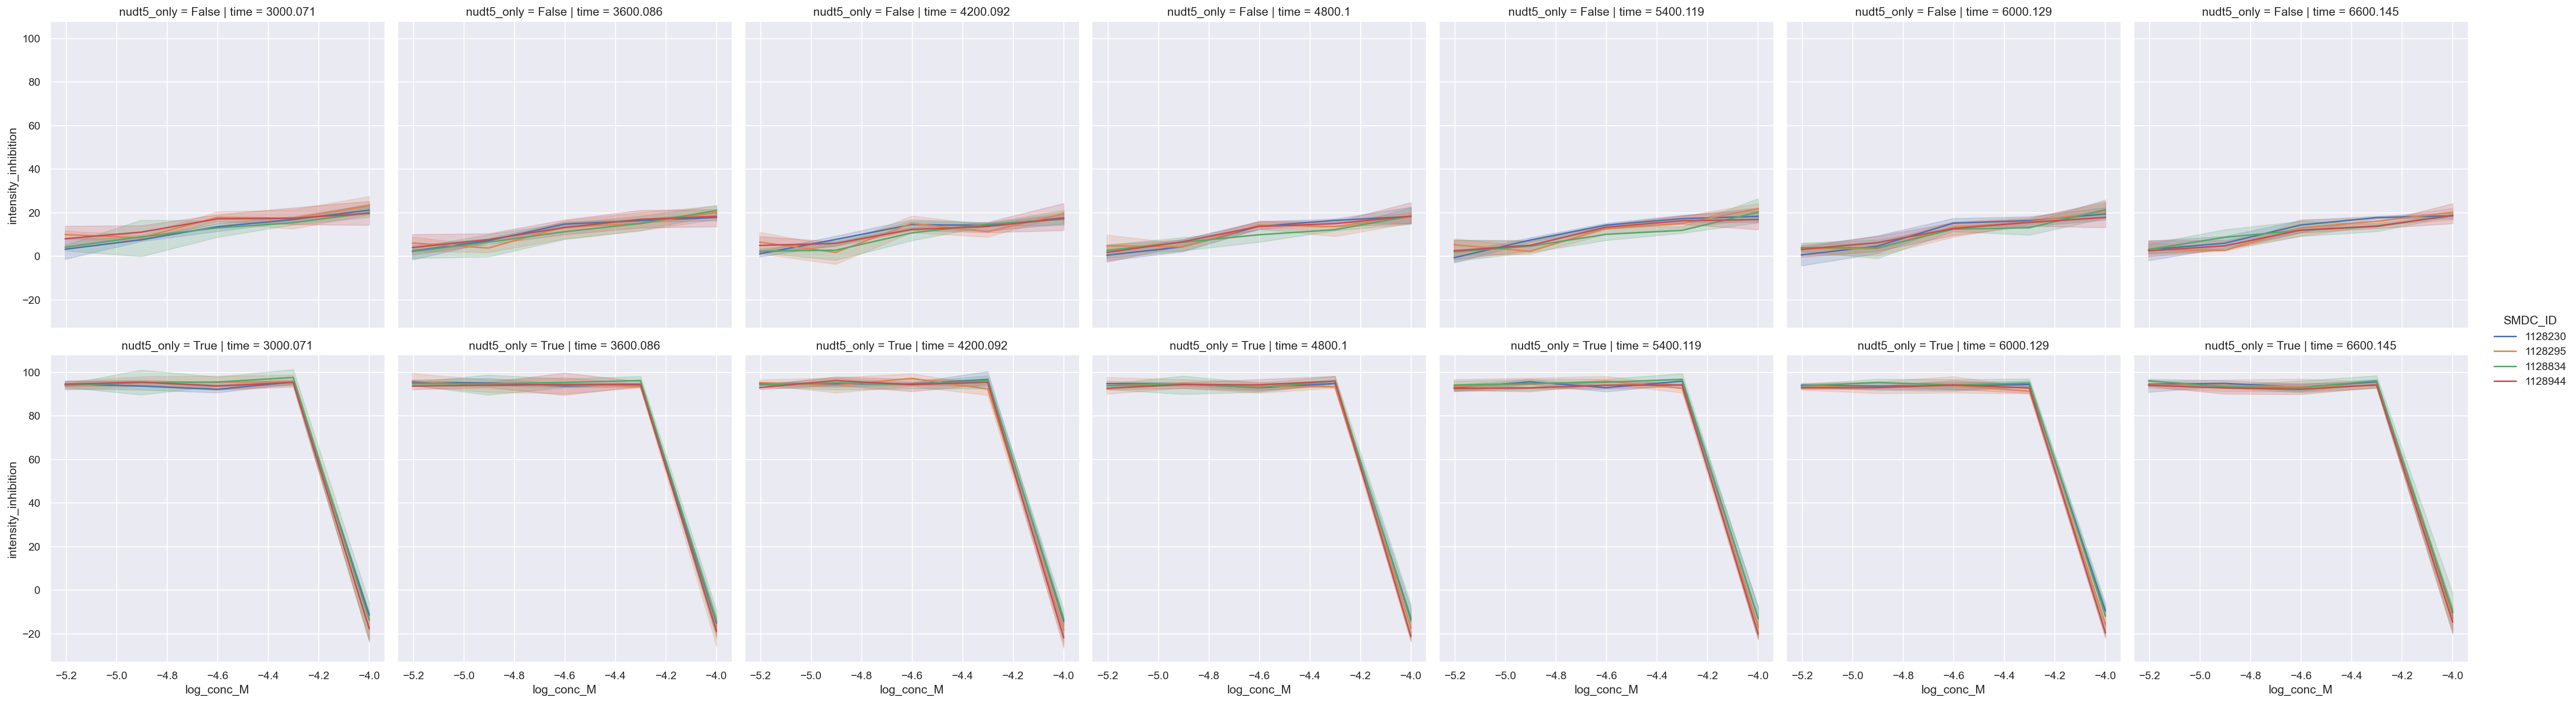

In [465]:
sns.relplot(data=dat_id_conc[(dat_id_conc.log_conc_M.notna())&(dat_id_conc.time>3000)], x='log_conc_M', y='intensity_inhibition', hue='SMDC_ID', col='time', row='nudt5_only', kind='line')

In [466]:
dat_id_conc.to_csv("/Volumes/Shared/SMDC/Screens/2025_users_temp/Deepthi/all_data/AMP_glo_processed.csv", index=False)

Text(0.5, 1.02, 'Inhibition at 3600s with background subtraction from NUDT5 wells <100uM')

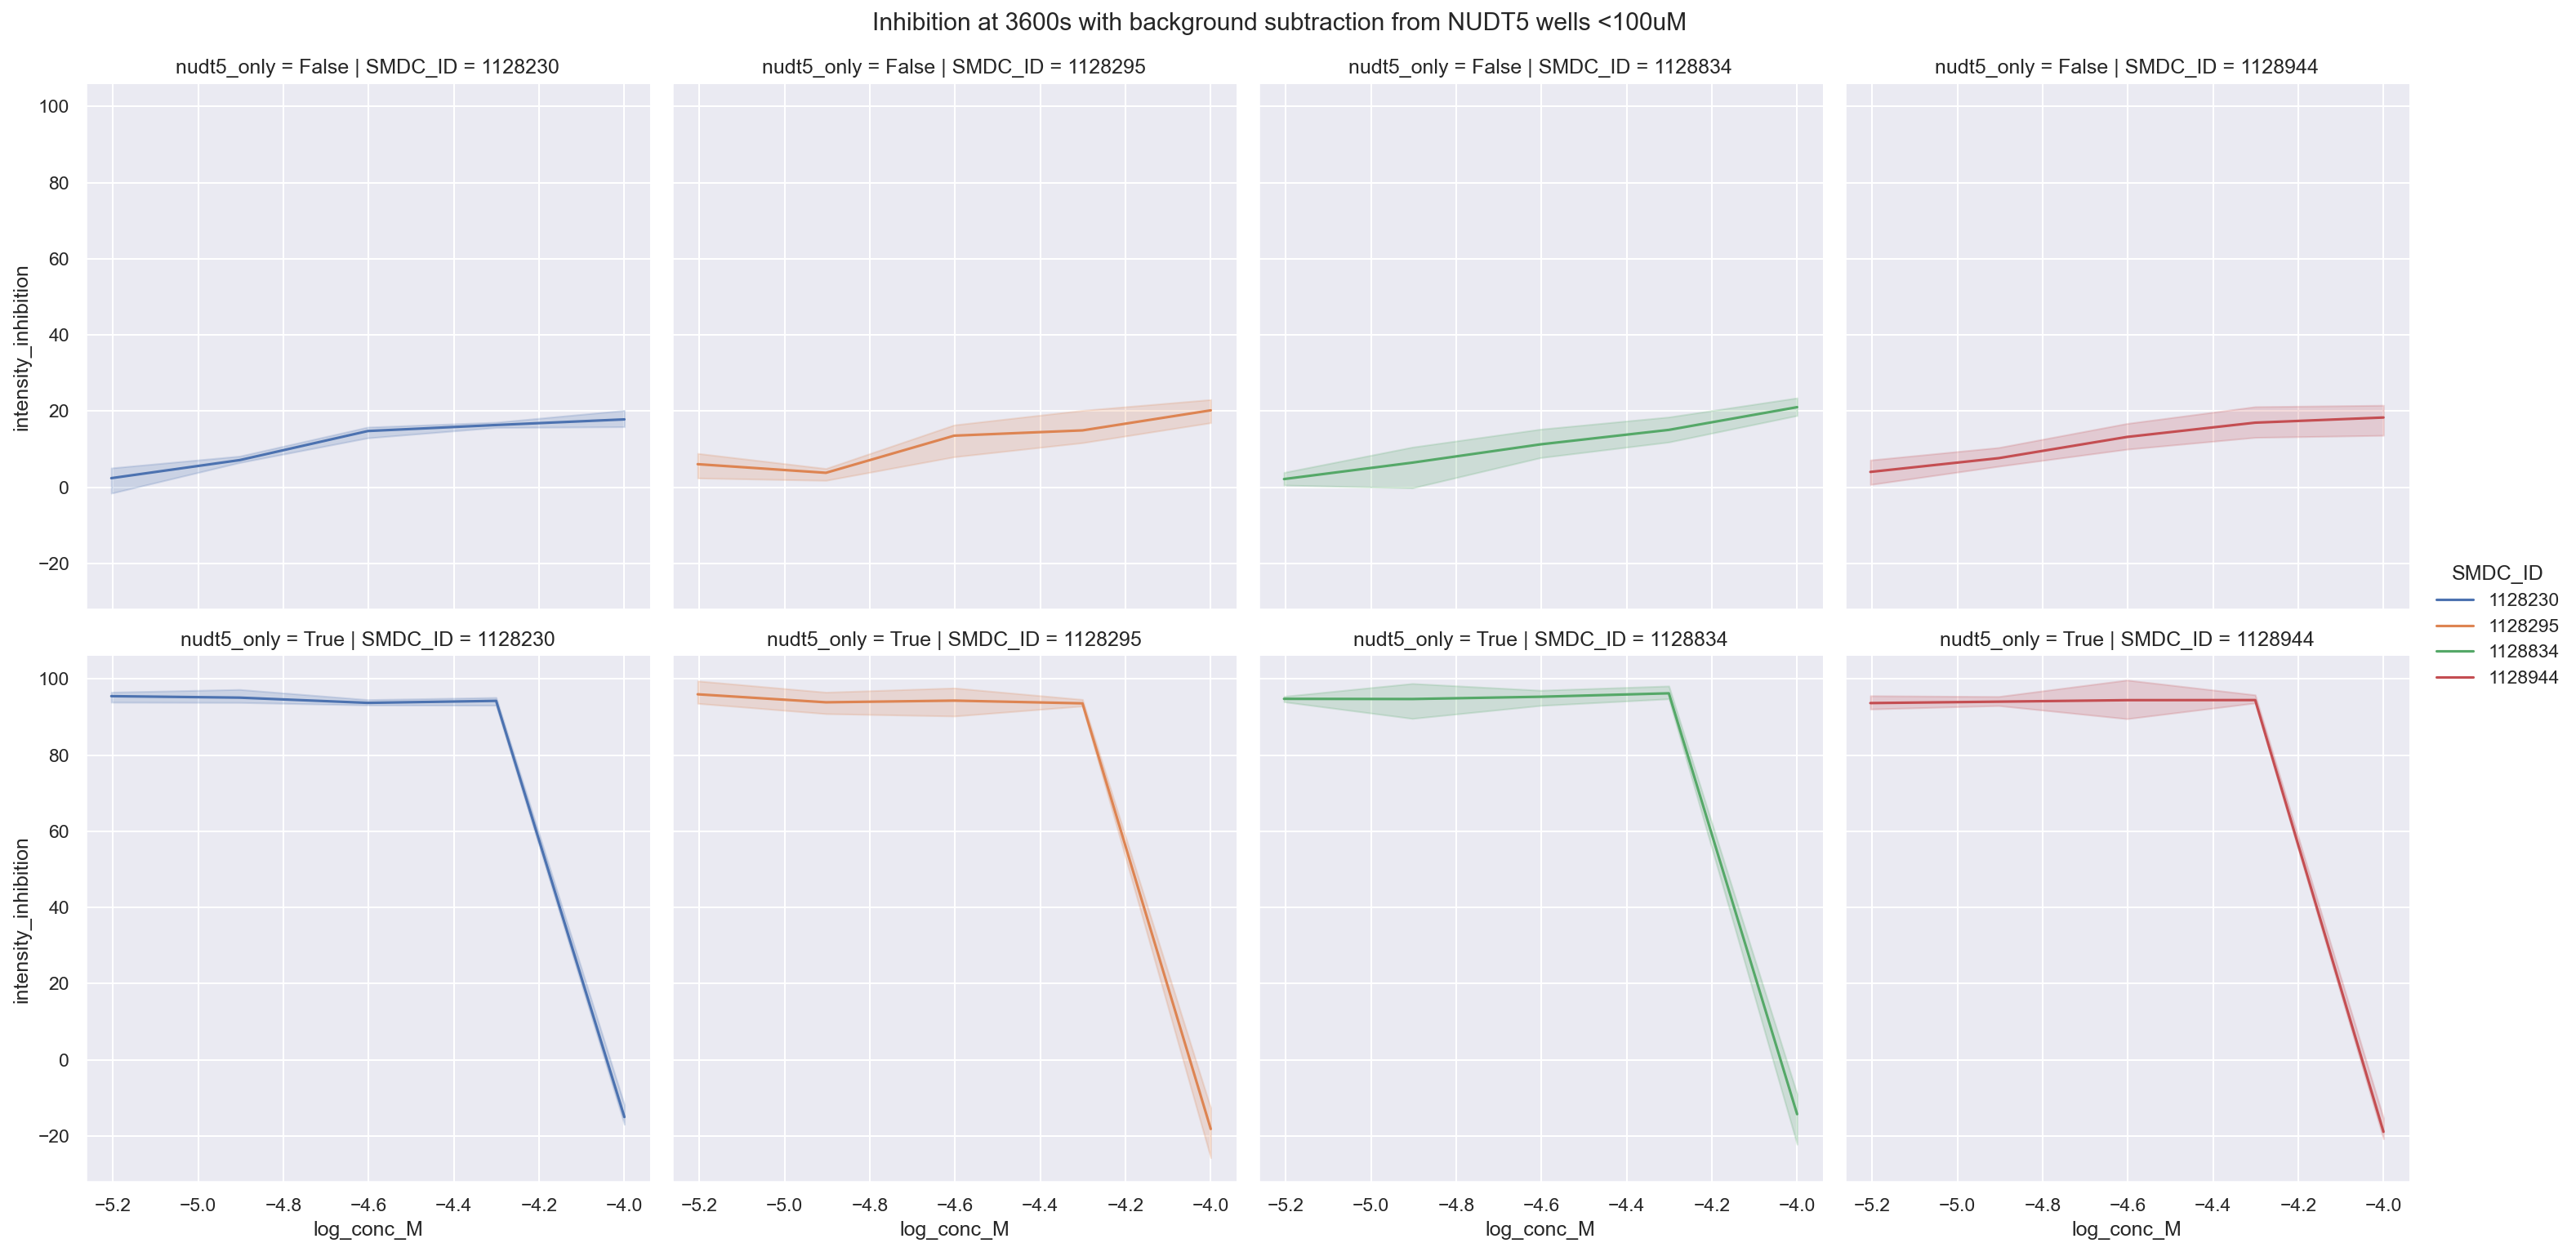

In [467]:
g=sns.relplot(data=dat_id_conc[(dat_id_conc.log_conc_M.notna())&(dat_id_conc.time==3600.086)], x='log_conc_M', y='intensity_inhibition', hue='SMDC_ID', col='SMDC_ID', row='nudt5_only', kind='line')
g.fig.suptitle("Inhibition at 3600s with background subtraction from NUDT5 wells <100uM", y=1.02)

Text(0.5, 1.02, 'Inhibition at 3600s with background subtraction from NUDT5 wells <100uM')

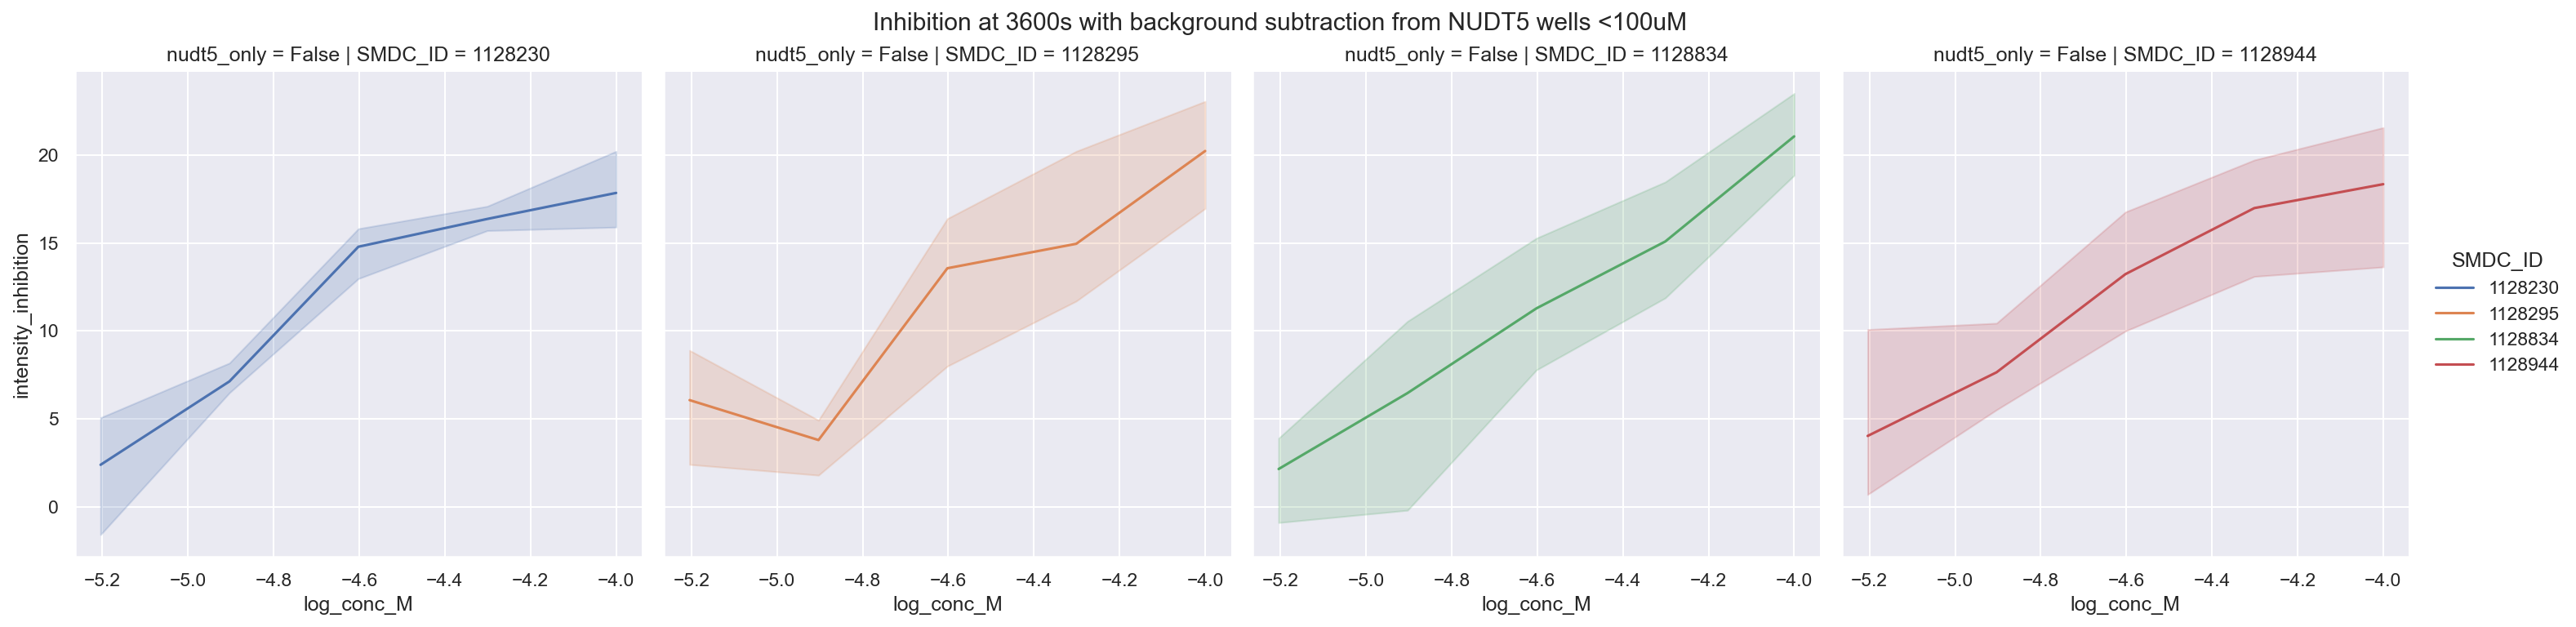

In [468]:
g=sns.relplot(data=dat_id_conc[(dat_id_conc.log_conc_M.notna())&(dat_id_conc.time==3600.086)&(dat_id_conc.nudt5_only==False)], x='log_conc_M', y='intensity_inhibition', hue='SMDC_ID', col='SMDC_ID', row='nudt5_only', kind='line')
g.fig.suptitle("Inhibition at 3600s with background subtraction from NUDT5 wells <100uM", y=1.02)

Text(0.5, 1.02, 'Inhibition at 3600s with background subtraction from NUDT5 wells <100uM')

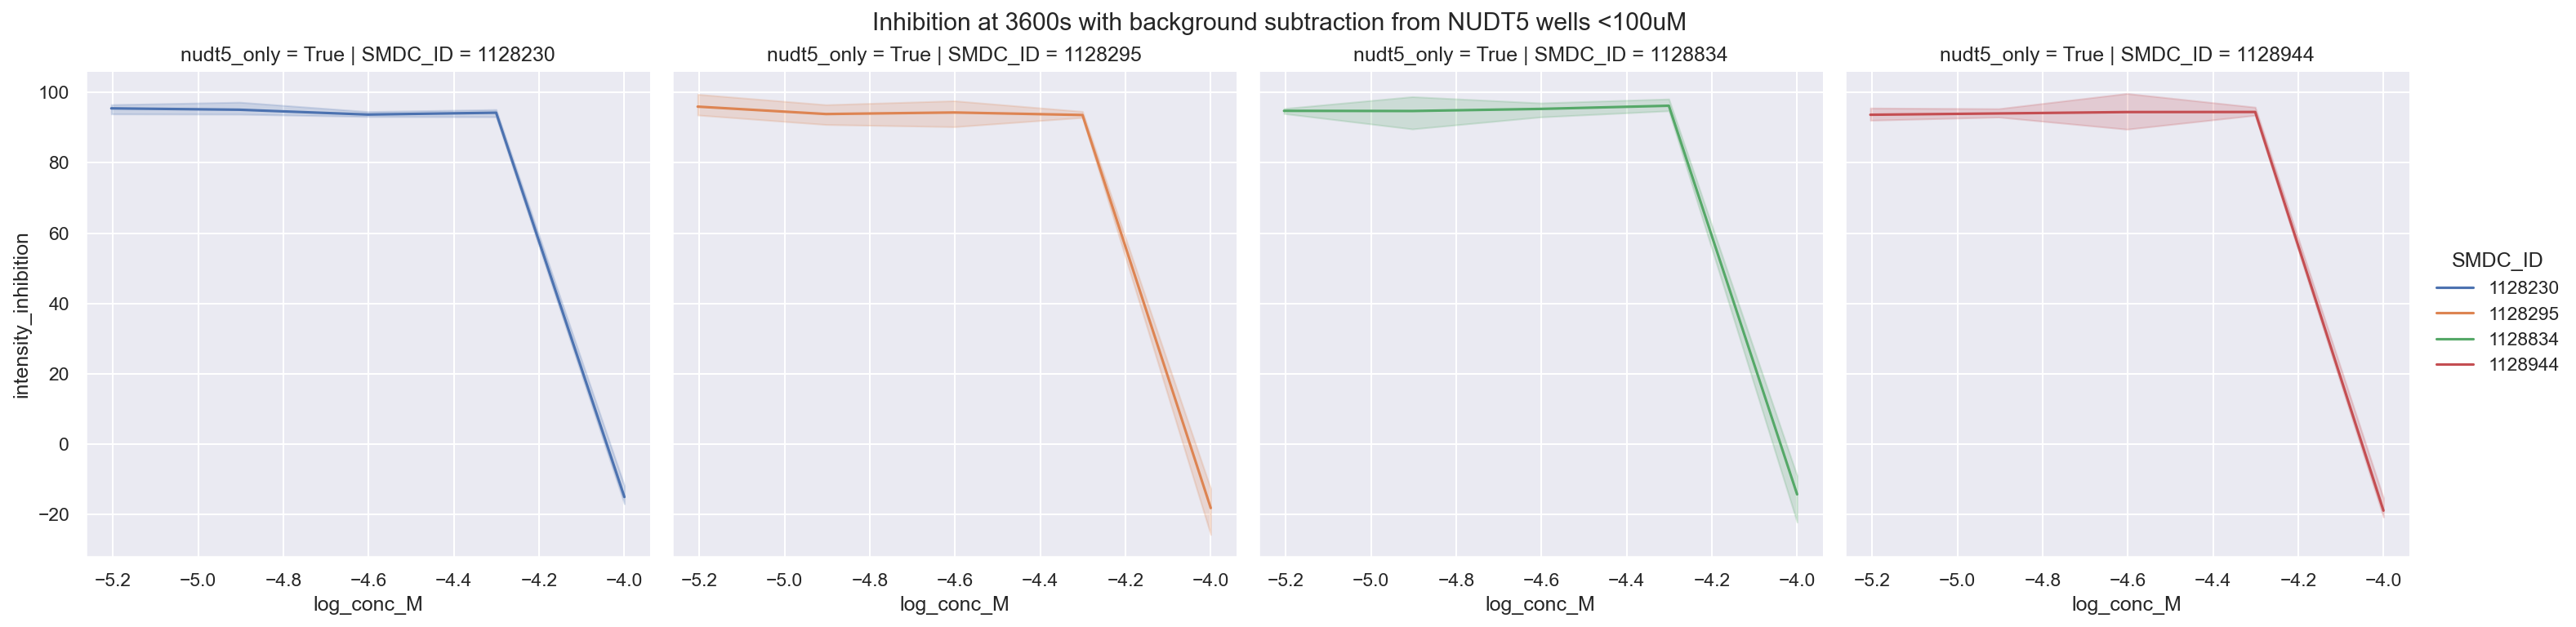

In [469]:
g=sns.relplot(data=dat_id_conc[(dat_id_conc.log_conc_M.notna())&(dat_id_conc.time==3600.086)&(dat_id_conc.nudt5_only==True)], x='log_conc_M', y='intensity_inhibition', hue='SMDC_ID', col='SMDC_ID', row='nudt5_only', kind='line')
g.fig.suptitle("Inhibition at 3600s with background subtraction from NUDT5 wells <100uM", y=1.02)

Text(0.5, 1.02, 'Inhibition at 3600s with background subtraction from NUDT5 wells <100uM')

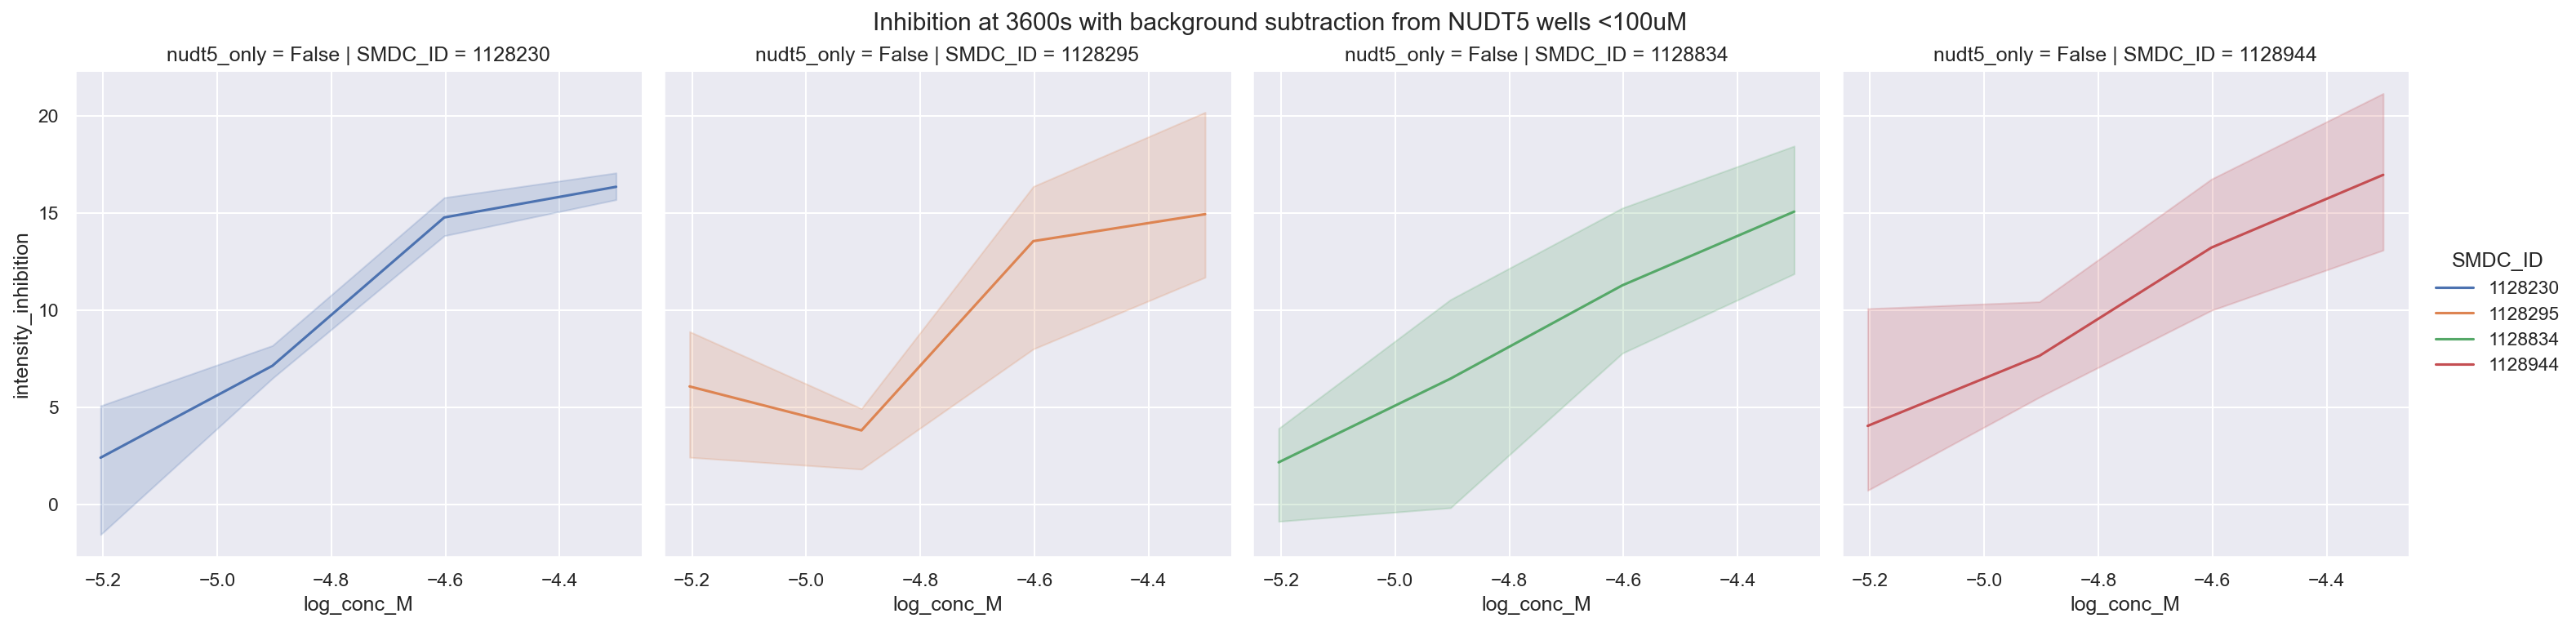

In [471]:
g=sns.relplot(data=dat_id_conc[(dat_id_conc.log_conc_M.notna())&(dat_id_conc.time==3600.086)&(dat_id_conc.nudt5_only==False)&(dat_id_conc.conc!=100)], x='log_conc_M', y='intensity_inhibition', hue='SMDC_ID', col='SMDC_ID', row='nudt5_only', kind='line')
g.fig.suptitle("Inhibition at 3600s with background subtraction from NUDT5 wells <100uM", y=1.02)